(gp-variational-stochastic)=
# Stochastic Variational Gaussian Processes

The {ref}`introduction <introduction>` fit an exact GP and a sparse VFE approximation, both with a Gaussian likelihood and full-batch training. Two walls appear as the data grows: exact inference factorizes an $N \times N$ kernel matrix ($O(N^3)$), and even the sparse VFE bound sums over all $N$ points every step, so a single gradient needs the whole dataset in memory.

Stochastic variational GPs (SVGP) remove both walls. Following {cite:t}`hensman-2013`, SVGP keeps an explicit variational distribution $q(\mathbf u)$ over the inducing values and optimizes it directly. That "uncollapsed" bound is a sum over data points, so it can be estimated from a minibatch and trained by stochastic gradient ascent that scales to millions of observations. The same move lets SVGP handle non-Gaussian likelihoods, though we stay Gaussian here.

This notebook builds the bound from the collapsed VFE bound of the intro, trains an SVGP on a 1D problem to expose its moving parts, then scales to a real 20,000-point spatial dataset. It assumes you have read the {ref}`introduction <introduction>` and are comfortable with variational inference. See the {doc}`kernel gallery </kernels/gallery>` and {doc}`user guide </user_guide/index>` for the surrounding API.

In [44]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
import pymc as pm
import pytensor.tensor as pt
from sklearn.preprocessing import StandardScaler

import ptgp as pg

rng = np.random.default_rng(0)

plt.rcParams.update(
    {
        "figure.figsize": (14, 5),
        "figure.dpi": 144,
        "figure.constrained_layout.use": True,
        "axes.grid": True,
        "grid.linewidth": 0.5,
        "grid.linestyle": "--",
    }
)

## From the collapsed bound to the uncollapsed bound

Both VFE and SVGP place $M$ inducing variables $\mathbf u = f(Z)$ at locations $Z$ and reason about the posterior through them. They differ in what they do with the variational distribution $q(\mathbf u)$.

**VFE (collapsed).** Titsias' bound {cite:t}`titsias-2009` solves for the optimal Gaussian $q(\mathbf u)$ in closed form and substitutes it back, leaving a bound in the kernel hyperparameters alone:

$$\mathcal L_{\text{VFE}} = \log \mathcal N\!\big(\mathbf y;\, \mathbf 0,\, Q_{ff} + \sigma^2 I\big) - \frac{1}{2\sigma^2}\operatorname{tr}(K_{ff} - Q_{ff}),\qquad Q_{ff}=K_{fu}K_{uu}^{-1}K_{uf}.$$

Elegant, but rigid: the closed form needs a Gaussian likelihood, and evaluating it touches all $N$ points at once, so every gradient step is $O(NM^2)$ over the full dataset.

**SVGP (uncollapsed).** Following {cite:t}`hensman-2013`, keep $q(\mathbf u) = \mathcal N(\mathbf m, S)$ explicit and optimize $\mathbf m$, $S$, and the inducing locations $Z$ jointly with the hyperparameters. The evidence lower bound becomes

$$\mathcal L = \sum_{i=1}^N \mathbb E_{q(f_i)}\!\big[\log p(y_i \mid f_i)\big] \;-\; \mathrm{KL}\!\big[q(\mathbf u)\,\|\,p(\mathbf u)\big].$$

The first term is a sum over data points; the second does not depend on the data at all. That structure is the whole point.

### Minibatching

Because the data term is a sum, an unbiased estimate comes from a random minibatch $B$:

$$\mathcal L \approx \frac{N}{\lvert B\rvert}\sum_{i \in B}\mathbb E_{q(f_i)}\!\big[\log p(y_i\mid f_i)\big] - \mathrm{KL}\!\big[q(\mathbf u)\,\|\,p(\mathbf u)\big].$$

The likelihood term is rescaled by $N/\lvert B\rvert$; the KL is left alone. PTGP applies exactly this scaling through `pg.objectives.elbo(svgp, X, y, n_data=N)`. Each step now costs $O(M^3 + \lvert B\rvert M^2)$ and never needs the full dataset in memory.

Each marginal $q(f_i)=\mathcal N(\mu_i,\sigma_i^2)$ follows from $q(\mathbf u)$ by conditioning; at a test point,

$$\mu(x_*) = k_{*u}K_{uu}^{-1}\mathbf m,\qquad \sigma^2(x_*) = k_{**} - k_{*u}K_{uu}^{-1}k_{u*} + k_{*u}K_{uu}^{-1}\,S\,K_{uu}^{-1}k_{u*}.$$

### Whitening

PTGP parameterizes $q$ over a whitened variable $\mathbf v$ with $p(\mathbf v)=\mathcal N(0, I)$ and $\mathbf u = R\mathbf v$, $RR^\top = K_{uu}$ (default `whiten=True`). This decorrelates the prior, improves conditioning, and collapses the KL to a form needing no kernel solve:

$$\mathrm{KL} = \tfrac12\big(\operatorname{tr} S + \mathbf m^\top \mathbf m - M - \log\lvert S\rvert\big).$$

The three methods trade off cost, training mode, and likelihood:

- **Exact GP**: $O(N^3)$ per step, full-batch, Gaussian likelihood only.
- **VFE**: $O(NM^2)$ per step, full-batch, Gaussian only.
- **SVGP**: $O(M^3 + \lvert B\rvert M^2)$ per step, minibatch, and any likelihood.

## A worked 1D example

To see the moving parts, start with a synthetic 1D regression: $N = 20{,}000$ noisy observations of $y = \sin x + \cos(0.75x)$. Small enough to plot, large enough that minibatching does real work. We standardize both axes so the priors below are sensibly scaled, and plot a random subsample.

In [45]:
N = 20_000

x = rng.uniform(-5.5, 5.5, size = N)
y = np.sin(x) + np.cos(0.75 * x) + 0.2 * rng.standard_normal(size = N)

x_scaler = StandardScaler().fit(x[:, None])
y_scaler = StandardScaler().fit(y[:, None])

X = x_scaler.transform(x[:, None])
Y = y_scaler.transform(y[:, None]).ravel()

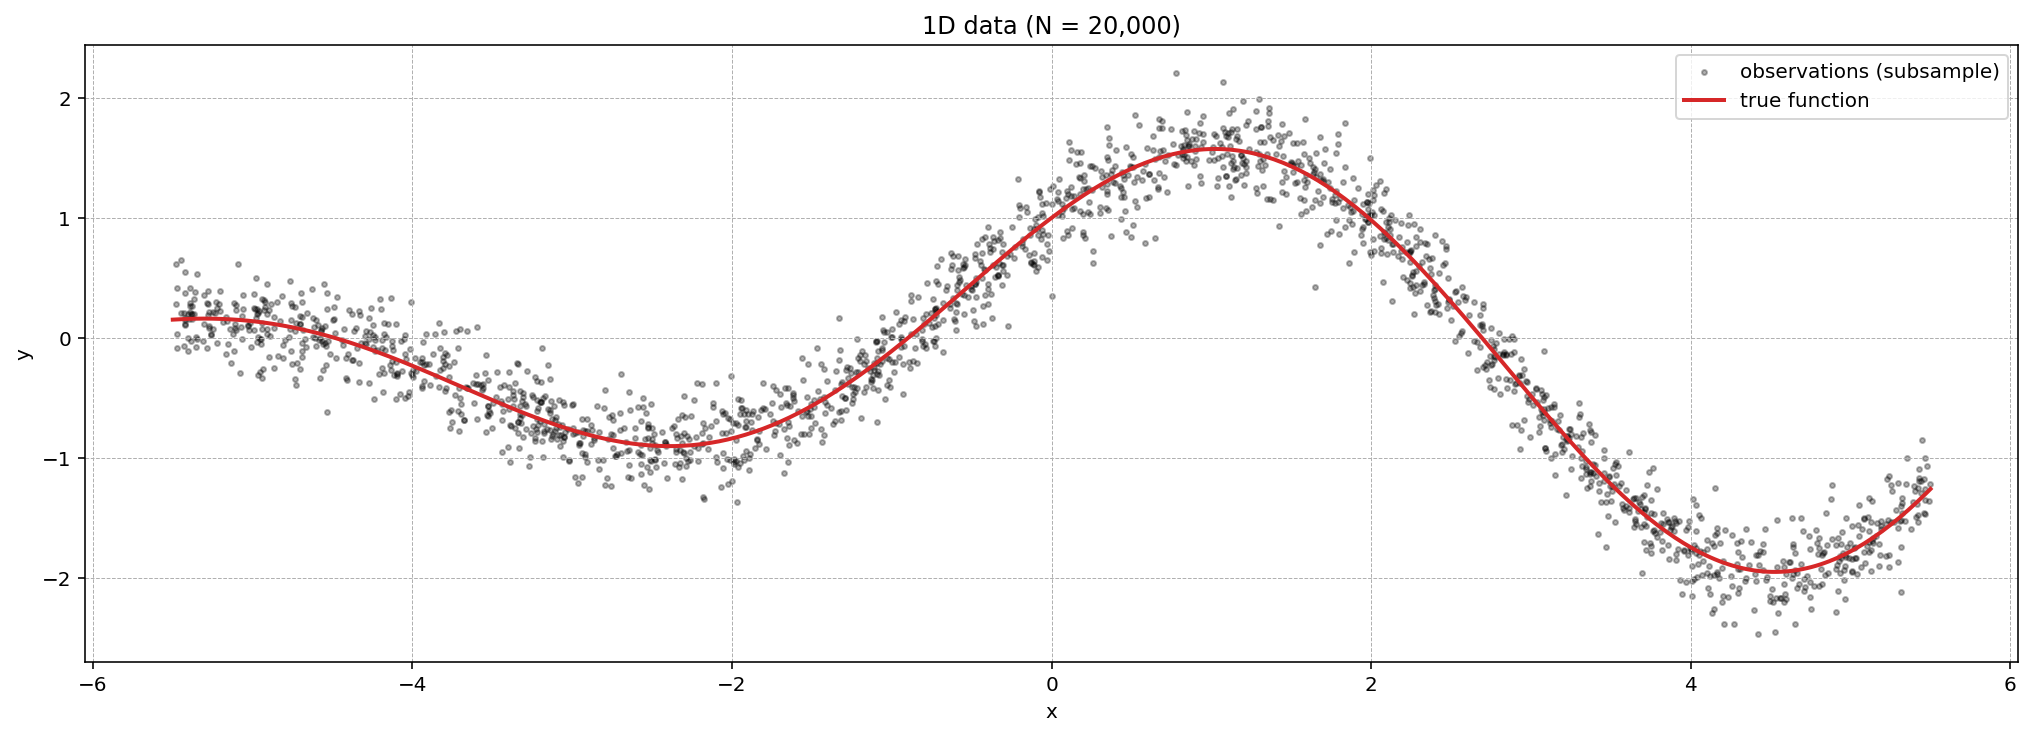

In [46]:
subsample = rng.choice(N, size = 2000, replace = False)
x_line = np.linspace(-5.5, 5.5, 400)

fig, ax = plt.subplots()

ax.scatter(
    x[subsample],
    y[subsample],
    s = 6,
    alpha = 0.3,
    c = "k",
    label = "observations (subsample)",
)
ax.plot(x_line, np.sin(x_line) + np.cos(0.75 * x_line), "C3", lw = 2, label = "true function")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"1D data (N = {N:,})")
ax.legend()

plt.show()

### Building the model

An SVGP needs a kernel, a likelihood, an inducing variable, and a variational distribution. We seed $M = 25$ inducing inputs with `greedy_variance_init` (the pivoted-Cholesky heuristic from the intro) and $q(\mathbf u)$ with `init_variational_params`. Passing the inducing inputs as a trainable `Points` variable makes their locations variational parameters too: training jointly optimizes the kernel hyperparameters, the noise, $q(\mathbf u)$, and the inducing locations $Z$.

In [47]:
M = 25

inducing_kernel = pg.kernels.ExpQuad(input_dim = 1, ls = 0.5)
Z_init = pg.inducing.greedy_variance_init(X, M = M, kernel = inducing_kernel, rng = 0)[0].Z

Z_var = pt.matrix("Z", shape = (M, 1))
inducing = pg.inducing.Points(Z_var, Z_init = Z_init)
vp = pg.gp.init_variational_params(M = M)

X_var = pt.matrix("X", shape = (None, 1))
y_var = pt.vector("y", shape = (None,))

with pm.Model() as model_1d:
    ls = pm.InverseGamma("ls", alpha = 3.0, beta = 1.0)
    eta = pm.Exponential("eta", scale = 1.0)
    sigma = pm.HalfNormal("sigma", sigma = 1.0)

    kernel = eta**2 * pg.kernels.ExpQuad(input_dim = 1, ls = ls)
    svgp = pg.gp.SVGP(
        kernel = kernel,
        likelihood = pg.likelihoods.Gaussian(sigma = sigma),
        inducing_variable = inducing,
        variational_params = vp,
        whiten = True,
    )

### Training

`compile_training_step` compiles the minibatch-scaled ELBO and its gradient into a single Adam step that updates every trainable parameter in place. We wrap `pg.objectives.elbo` to bake in the `n_data = N` scaling, pass the variational parameters as `extra_vars`, and run 2,000 minibatch steps of size 256 under an exponentially decaying learning rate.

In [48]:
def elbo_objective(gp, X, y):
    return pg.objectives.elbo(gp, X, y, n_data = N).elbo


train_step, shared_params, shared_extras = pg.optim.compile_training_step(
    objective_fn = elbo_objective,
    gp_model = svgp,
    X_var = X_var,
    y_var = y_var,
    model = model_1d,
    extra_vars = svgp.extra_vars,
    extra_init = svgp.extra_init,
    learning_rate = pg.optim.schedules.exponential_decay(1e-2, decay_rate = 0.3, decay_steps = 2000),
)

batch_size = 256
n_steps = 2000

losses = []
for step in range(n_steps):
    batch = rng.choice(N, size = batch_size, replace = False)
    losses.append(float(train_step(X[batch], Y[batch])))

params = pg.optim.get_trained_params(model = model_1d, shared_params = shared_params)
print("recovered:", {name: round(float(value), 3) for name, value in params.items()})

recovered: {'ls': 0.306, 'eta': 0.474, 'sigma': 0.192}


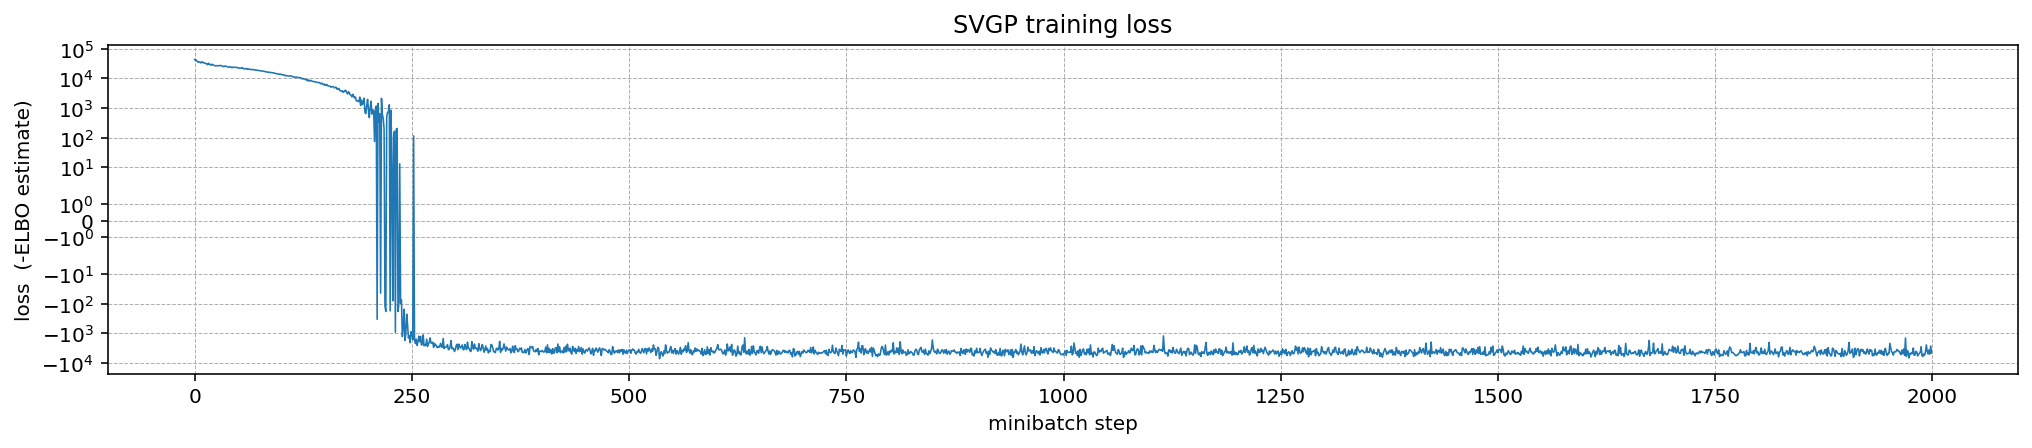

In [49]:
fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(losses, lw=0.8)
ax.set_yscale("symlog")

ax.set_xlabel("minibatch step")
ax.set_ylabel("loss  (-ELBO estimate)")
ax.set_title("SVGP training loss")

plt.show()

In [50]:
def to_y(values):
    return y_scaler.inverse_transform(np.reshape(values, (-1, 1))).ravel()


X_new = pt.matrix("X_new", shape = (None, 1))
predict = pg.optim.compile_predict(
    gp_model = svgp,
    X_new_var = X_new,
    model = model_1d,
    shared_params = shared_params,
    shared_extras = shared_extras,
)
predict_y = pg.optim.compile_predict(
    gp_model = svgp,
    X_new_var = X_new,
    model = model_1d,
    shared_params = shared_params,
    shared_extras = shared_extras,
    incl_lik = True,
)

grid = np.linspace(-6, 6, 300)[:, None]
grid_x = x_scaler.inverse_transform(grid).ravel()

mu, var = predict(grid)
_, var_y = predict_y(grid)
sd = np.sqrt(var)
sd_y = np.sqrt(var_y)

mean = to_y(mu)
f_lo = to_y(mu - 2 * sd)
f_hi = to_y(mu + 2 * sd)
y_lo = to_y(mu - 2 * sd_y)
y_hi = to_y(mu + 2 * sd_y)

Z_final = shared_extras[-1].get_value()
z_init_x = x_scaler.inverse_transform(Z_init).ravel()
z_final_x = x_scaler.inverse_transform(Z_final).ravel()

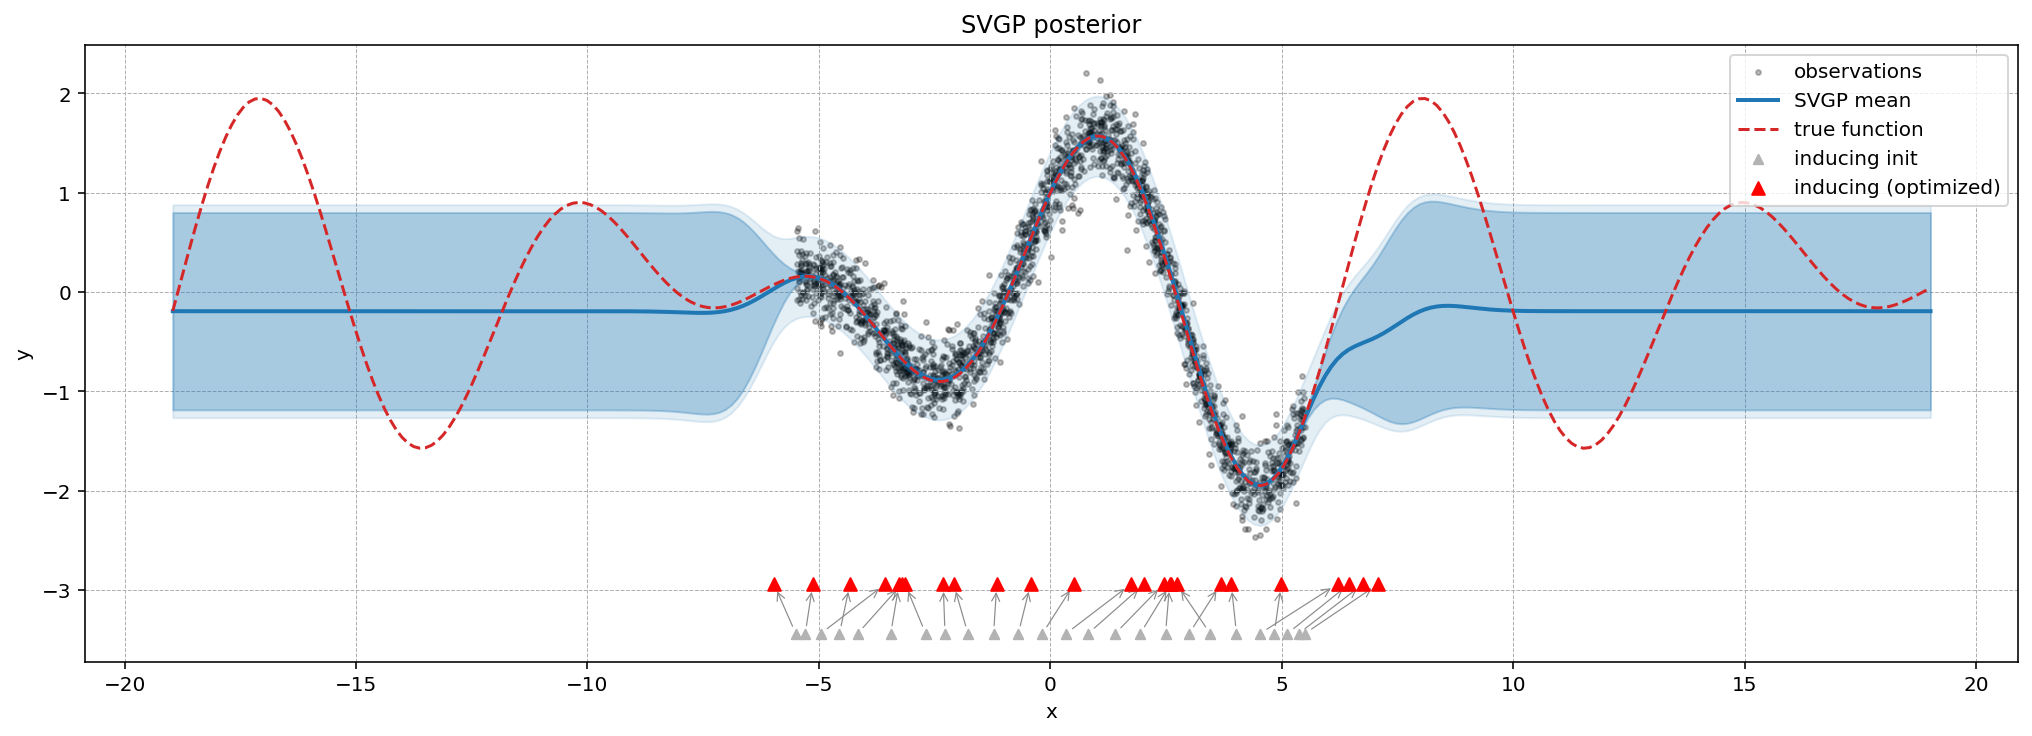

In [51]:
fig, ax = plt.subplots()

ax.scatter(x[subsample], y[subsample], s = 6, alpha = 0.25, c = "k", zorder = 1, label = "observations")
ax.plot(grid_x, mean, "C0", lw = 2, zorder = 3, label = "SVGP mean")
ax.fill_between(grid_x, y_lo, y_hi, color = "C0", alpha = 0.12, zorder = 2)
ax.fill_between(grid_x, f_lo, f_hi, color = "C0", alpha = 0.30, zorder = 2)
ax.plot(
    grid_x,
    np.sin(grid_x) + np.cos(0.75 * grid_x),
    "C3",
    lw = 1.5,
    ls = "--",
    zorder = 4,
    label = "true function",
)

# inducing points migrate from their init (gray) to their optimized locations (red)
y_init = y.min() - 0.85
y_final = y.min() - 0.35
for x_from, x_to in zip(z_init_x, z_final_x):
    ax.annotate(
        "",
        xy = (x_to, y_final),
        xytext = (x_from, y_init),
        arrowprops = dict(arrowstyle = "->", color = "0.55", lw = 0.6, shrinkA = 4, shrinkB = 4),
    )
ax.scatter(
    z_init_x,
    np.full(M, y_init),
    marker = "^",
    c = "0.7",
    s = 22,
    zorder = 4,
    label = "inducing init",
)
ax.scatter(
    z_final_x,
    np.full(M, y_final),
    marker = "^",
    c = "r",
    s = 40,
    zorder = 5,
    label = "inducing (optimized)",
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("SVGP posterior")
ax.legend(loc = "upper right")

plt.show()

### Looking inside: the variational posterior over $\mathbf u$

Because SVGP keeps $q(\mathbf u)$ explicit, we can inspect what the model learned at the inducing inputs directly. Predicting the latent function at $Z$ gives the posterior over the inducing values in function space (whitening handled for us). The error bars are tight where data pins the function down and widen at the edges.

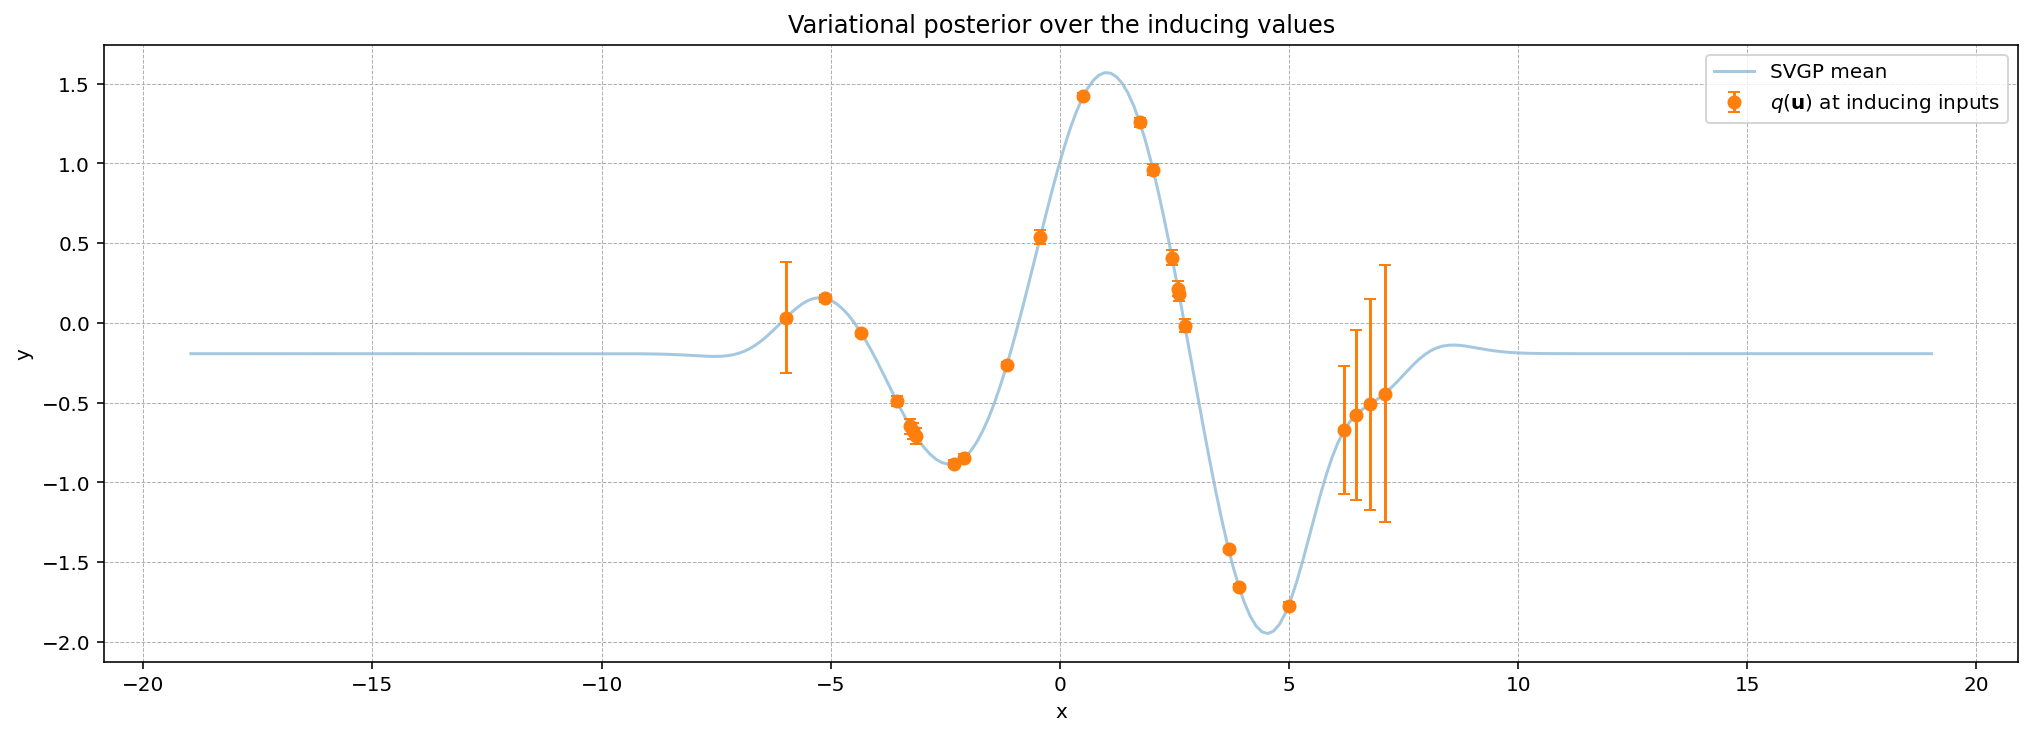

In [52]:
mu_z, var_z = predict(Z_final)
sd_z = np.sqrt(var_z)

mean_z = to_y(mu_z)
lo_z = to_y(mu_z - 2 * sd_z)
hi_z = to_y(mu_z + 2 * sd_z)
order = np.argsort(z_final_x)

fig, ax = plt.subplots()

ax.plot(grid_x, mean, "C0", alpha = 0.4, zorder = 1, label = "SVGP mean")
ax.errorbar(
    z_final_x[order],
    mean_z[order],
    yerr = [(mean_z - lo_z)[order], (hi_z - mean_z)[order]],
    fmt = "o",
    color = "C1",
    capsize = 3,
    zorder = 3,
    label = r"$q(\mathbf{u})$ at inducing inputs",
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Variational posterior over the inducing values")
ax.legend(loc = "upper right")

plt.show()

## Scaling to real data: California housing

The 1D example fit in seconds; its point was mechanics, not size. Here SVGP earns its keep. The California housing dataset {cite:p}`pace-barry-1997` records 20,640 census block groups; we model the spatial surface of log median house value from longitude and latitude alone.

At $N = 20{,}640$ an exact GP would factorize a $20{,}640 \times 20{,}640$ matrix, and VFE would revisit all 20,640 points every step. SVGP just draws a minibatch. We standardize the coordinates, take the log of the price (right-skewed and value-capped), and standardize that too.

In [53]:
housing_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing_csv = Path("housing.csv")
if not housing_csv.exists():
    pd.read_csv(housing_url).to_csv(housing_csv, index = False)  # cache locally
housing = pd.read_csv(housing_csv)

lonlat = housing[["longitude", "latitude"]].to_numpy(float)
price = np.log(housing["median_house_value"].to_numpy(float))

xy_scaler = StandardScaler().fit(lonlat)
p_scaler = StandardScaler().fit(price[:, None])

XY = xy_scaler.transform(lonlat)
P = p_scaler.transform(price[:, None]).ravel()
N2 = XY.shape[0]

In [54]:
# California outline (GeoJSON) to mask predictions and overlay the coastline
geojson_url = "https://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_500k.json"
geojson_cache = Path("california.geojson")
if not geojson_cache.exists():
    urllib.request.urlretrieve(geojson_url, geojson_cache)

with open(geojson_cache) as f:
    states = json.load(f)["features"]
california = next(s["geometry"] for s in states if s["properties"]["NAME"] == "California")

if california["type"] == "Polygon":
    ca_rings = [california["coordinates"][0]]
else:
    ca_rings = [polygon[0] for polygon in california["coordinates"]]
ca_path = MplPath(np.array(max(ca_rings, key = len))[:, :2])


def draw_california(ax):
    for ring in ca_rings:
        lon = np.array(ring)[:, 0]
        lat = np.array(ring)[:, 1]
        ax.plot(lon, lat, color = "0.25", lw = 0.8, zorder = 6)

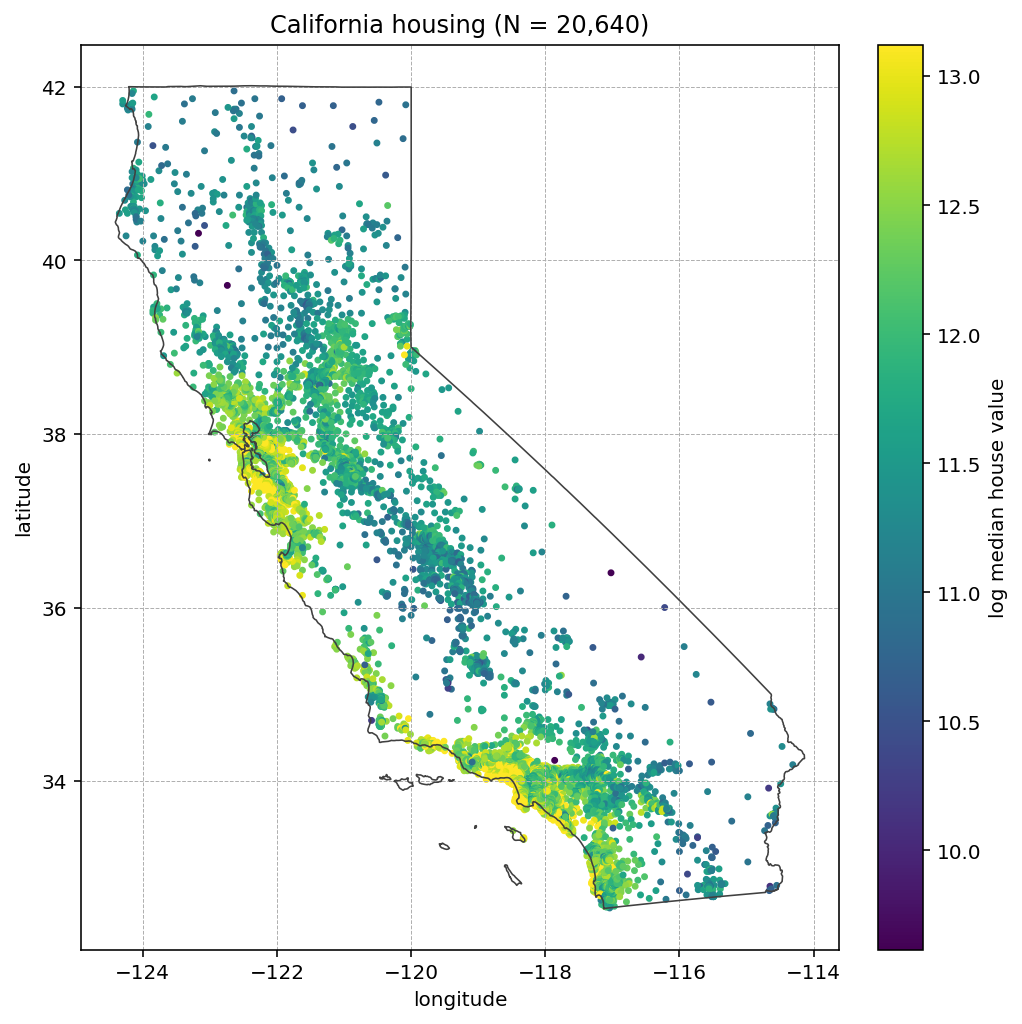

In [55]:
fig, ax = plt.subplots(figsize = (7, 7))

scatter = ax.scatter(lonlat[:, 0], lonlat[:, 1], c = price, s = 6, cmap = "viridis")
draw_california(ax)

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"California housing (N = {N2:,})")
fig.colorbar(scatter, ax = ax, label = "log median house value")

plt.show()

### Building and training

Same shape as the 1D model, with a two-dimensional Matern 5/2 kernel and $M = 150$ inducing inputs. `greedy_variance_init` seeds them space-filling across the state; from there they are optimized along with everything else, migrating toward where the price surface has structure. We train for 5,000 minibatch steps of size 512 and plot the loss to confirm it settles.

In [56]:
M2 = 150

inducing_kernel_2d = pg.kernels.Matern52(input_dim = 2, ls = 0.5)
Z_init_2d = pg.inducing.greedy_variance_init(XY, M = M2, kernel = inducing_kernel_2d, rng = 0)[0].Z

Z_var_2d = pt.matrix("Z2", shape = (M2, 2))
inducing2 = pg.inducing.Points(Z_var_2d, Z_init = Z_init_2d)
vp2 = pg.gp.init_variational_params(M = M2)

XY_var = pt.matrix("XY", shape = (None, 2))
p_var = pt.vector("p", shape = (None,))

with pm.Model() as model_2d:
    ls = pm.InverseGamma("ls", alpha = 3.0, beta = 1.0)
    eta = pm.Exponential("eta", scale = 1.0)
    sigma = pm.HalfNormal("sigma", sigma = 1.0)

    kernel = eta**2 * pg.kernels.Matern52(input_dim = 2, ls = ls)
    svgp2 = pg.gp.SVGP(
        kernel = kernel,
        likelihood = pg.likelihoods.Gaussian(sigma = sigma),
        inducing_variable = inducing2,
        variational_params = vp2,
        whiten = True,
    )

In [57]:
def elbo_objective_2d(gp, X, y):
    return pg.objectives.elbo(gp, X, y, n_data = N2).elbo


train_step_2d, shared_params_2d, shared_extras_2d = pg.optim.compile_training_step(
    objective_fn = elbo_objective_2d,
    gp_model = svgp2,
    X_var = XY_var,
    y_var = p_var,
    model = model_2d,
    extra_vars = svgp2.extra_vars,
    extra_init = svgp2.extra_init,
    learning_rate = pg.optim.schedules.exponential_decay(1e-2, decay_rate = 0.3, decay_steps = 3000),
)

batch_size_2d = 512
n_steps_2d = 5000

losses_2d = []
for step in range(n_steps_2d):
    batch = rng.choice(N2, size = batch_size_2d, replace = False)
    losses_2d.append(float(train_step_2d(XY[batch], P[batch])))

params_2d = pg.optim.get_trained_params(model = model_2d, shared_params = shared_params_2d)
print("recovered:", {name: round(float(value), 3) for name, value in params_2d.items()})

recovered: {'ls': 0.205, 'eta': 0.726, 'sigma': 0.583}


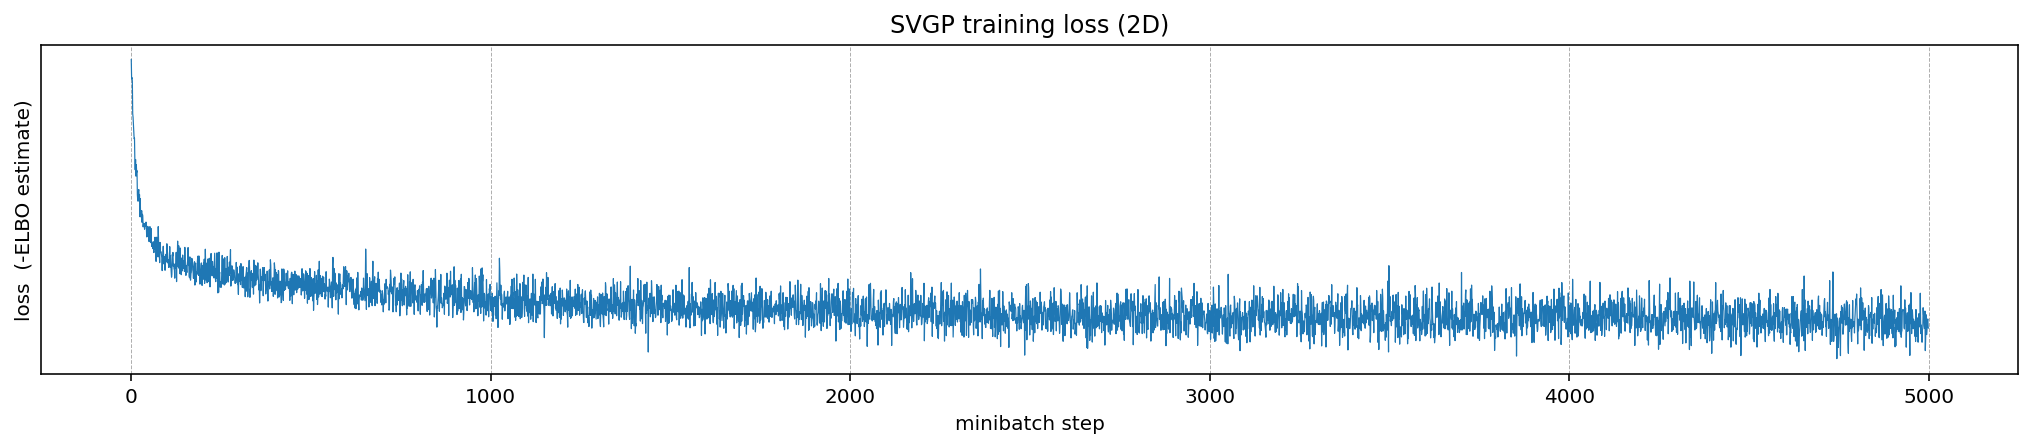

In [58]:
fig, ax = plt.subplots(figsize = (14, 3))

ax.plot(losses_2d, lw = 0.6)
ax.set_yscale("symlog")

ax.set_xlabel("minibatch step")
ax.set_ylabel("loss  (-ELBO estimate)")
ax.set_title("SVGP training loss (2D)")

plt.show()

In [59]:
XY_new = pt.matrix("XY_new", shape = (None, 2))
predict_2d = pg.optim.compile_predict(
    gp_model = svgp2,
    X_new_var = XY_new,
    model = model_2d,
    shared_params = shared_params_2d,
    shared_extras = shared_extras_2d,
)

resolution = 200
grid_lon, grid_lat = np.meshgrid(
    np.linspace(lonlat[:, 0].min(), lonlat[:, 0].max(), resolution),
    np.linspace(lonlat[:, 1].min(), lonlat[:, 1].max(), resolution),
)
grid_lonlat = np.column_stack([grid_lon.ravel(), grid_lat.ravel()])

mu_grid, _ = predict_2d(xy_scaler.transform(grid_lonlat))
mean_price = p_scaler.inverse_transform(mu_grid[:, None]).ravel()
mean_price[~ca_path.contains_points(grid_lonlat)] = np.nan  # mask outside California
mean_price = mean_price.reshape(grid_lon.shape)

z_init = xy_scaler.inverse_transform(Z_init_2d)
z_final = xy_scaler.inverse_transform(shared_extras_2d[-1].get_value())

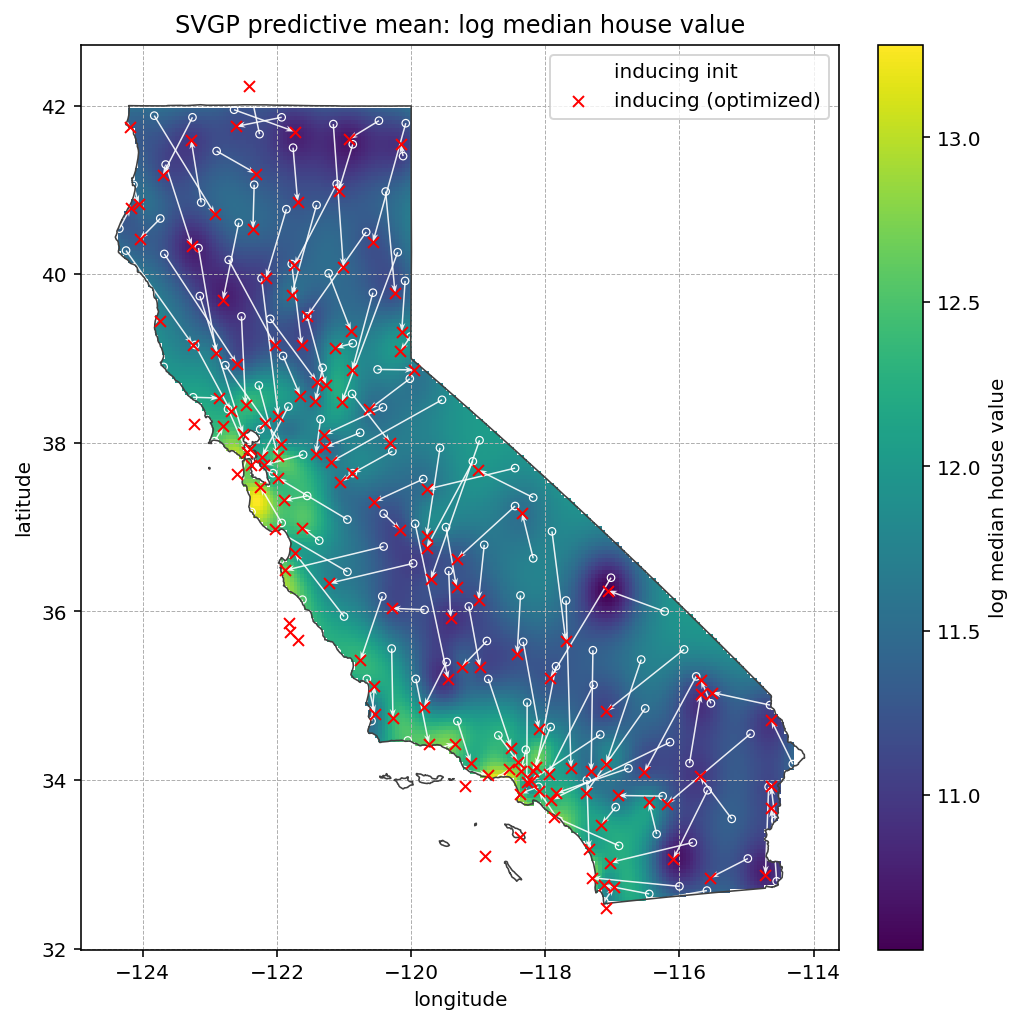

In [60]:
fig, ax = plt.subplots(figsize = (7, 7))

mesh = ax.pcolormesh(grid_lon, grid_lat, mean_price, cmap = "viridis", shading = "auto")
draw_california(ax)

ax.quiver(
    z_init[:, 0],
    z_init[:, 1],
    z_final[:, 0] - z_init[:, 0],
    z_final[:, 1] - z_init[:, 1],
    angles = "xy",
    scale_units = "xy",
    scale = 1,
    color = "w",
    width = 0.002,
    headwidth = 4,
    headlength = 6,
    alpha = 0.9,
    zorder = 5,
)
ax.scatter(
    z_init[:, 0],
    z_init[:, 1],
    s = 14,
    facecolors = "none",
    edgecolors = "w",
    lw = 0.6,
    zorder = 4,
    label = "inducing init",
)
ax.scatter(
    z_final[:, 0],
    z_final[:, 1],
    marker = "x",
    c = "r",
    s = 30,
    lw = 1.0,
    zorder = 6,
    label = "inducing (optimized)",
)

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("SVGP predictive mean: log median house value")
ax.legend(loc = "upper right")
fig.colorbar(mesh, ax = ax, label = "log median house value")

plt.show()

## Next steps

- {ref}`Introduction to PTGP <introduction>`: exact GPs and the VFE bound this notebook builds on.
- {doc}`Kernel gallery </kernels/gallery>` and {doc}`user guide </user_guide/index>`: kernels, likelihoods, inducing-point strategies, and training in depth.
- Non-Gaussian likelihoods: the uncollapsed ELBO's data term is an expectation under $q(f_i)$, which PTGP evaluates by Gauss-Hermite quadrature for any `ptgp.likelihoods` member, so swapping `Gaussian` for `Bernoulli`, `Poisson`, or `StudentT` is a one-line change.
- Variational Fourier Features replace pseudo-input inducing points with a Fourier basis for 1D Matern kernels; a dedicated notebook is forthcoming.

## References

```{bibliography}
```